In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
park_agg = pd.read_csv("../data/clean/park_agg.csv")
park_agg["Crowding Levels"] = pd.qcut(park_agg['Recreation Visits'], q=3, labels=['Low', 'Medium', 'High'])
print(park_agg['Crowding Levels'].value_counts())

Crowding Levels
Low       20
High      20
Medium    19
Name: count, dtype: int64


In [5]:
nb_feats = ["Non Recreation Visits","Non Recreation Hours","Concessioner Lodging","Concessioner Camping","Tent Campers","RV Campers",
"Backcountry","Miscellaneous Overnight Stays","Number of Activities","Entrance Fees"]
x = park_agg[nb_feats].copy()
y = park_agg["Crowding Levels"].copy()

Non Recreation Visits            0
Non Recreation Hours             0
Concessioner Lodging             0
Concessioner Camping             0
Tent Campers                     0
RV Campers                       0
Backcountry                      0
Miscellaneous Overnight Stays    0
Number of Activities             0
Entrance Fees                    0
dtype: int64
Non Recreation Visits            0.0
Non Recreation Hours             0.0
Concessioner Lodging             0.0
Concessioner Camping             0.0
Tent Campers                     0.0
RV Campers                       0.0
Backcountry                      0.0
Miscellaneous Overnight Stays    0.0
Number of Activities             8.0
Entrance Fees                    0.0
dtype: float64


In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)
print("\nTraining class counts:")
print(y_train.value_counts())
print("\nTesting class counts:")
print(y_test.value_counts())

Training set shape: (47, 10)
Testing set shape: (12, 10)

Training class counts:
Crowding Levels
Low       16
High      16
Medium    15
Name: count, dtype: int64

Testing class counts:
Crowding Levels
Low       4
Medium    4
High      4
Name: count, dtype: int64


In [28]:
x_train.head()

,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
45,10.000000,10.000000,0.000000,0.0,0.000000,0.000000,66.742424,0.000000,37.0,25.0
41,59113.416667,59113.416667,2808.287879,0.0,5026.136364,2229.159091,4206.022727,396.106061,36.0,30.0
26,893553.583333,893553.583333,880.568182,0.0,15014.083333,11120.121212,7737.674242,2183.303030,36.0,0.0
28,1950.545455,1950.545455,0.000000,0.0,967.674242,0.000000,284.628788,324.386364,8.0,25.0
50,548.166667,548.166667,0.000000,0.0,1071.893939,1528.295455,69.113636,195.181818,28.0,30.0


In [29]:
x_test.head()

,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
44,67427.840909,67427.840909,6218.477273,1114.19697,11570.136364,6743.053030,9946.007576,13.204545,54.0,30.0
7,0.000000,0.000000,0.000000,0.00000,843.128788,707.568182,6325.015152,91.530303,22.0,30.0
9,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,11.000000,0.000000,17.0,1.0
35,0.000000,0.000000,0.000000,0.00000,73.196970,0.000000,27.522727,26.712121,38.0,0.0
54,20063.469697,20063.469697,0.000000,0.00000,372.575758,433.189394,36.409091,53.643939,25.0,0.0


In [30]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled_df = pd.DataFrame(x_train_scaled,columns=x_train.columns,index=x_train.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled,columns=x_test.columns,index=x_test.index)
print("Training Data Before Scaling:")
display(x_train.head())

print("Training Data After Scaling:")
display(x_train_scaled_df.head().round(3))

Training Data Before Scaling:


,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
45,10.000000,10.000000,0.000000,0.0,0.000000,0.000000,66.742424,0.000000,37.0,25.0
41,59113.416667,59113.416667,2808.287879,0.0,5026.136364,2229.159091,4206.022727,396.106061,36.0,30.0
26,893553.583333,893553.583333,880.568182,0.0,15014.083333,11120.121212,7737.674242,2183.303030,36.0,0.0
28,1950.545455,1950.545455,0.000000,0.0,967.674242,0.000000,284.628788,324.386364,8.0,25.0
50,548.166667,548.166667,0.000000,0.0,1071.893939,1528.295455,69.113636,195.181818,28.0,30.0


Training Data After Scaling:


,Non Recreation Visits,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
45,0.000,0.000,0.000,0.0,0.000,0.000,0.003,0.000,0.604,0.714
41,0.066,0.066,0.051,0.0,0.164,0.117,0.174,0.071,0.583,0.857
26,1.000,1.000,0.016,0.0,0.491,0.584,0.320,0.390,0.583,0.000
28,0.002,0.002,0.000,0.0,0.032,0.000,0.012,0.058,0.000,0.714
50,0.001,0.001,0.000,0.0,0.035,0.080,0.003,0.035,0.417,0.857


In [10]:
model = MultinomialNB()
model.fit(x_train_scaled_df, y_train)
pred_y = model.predict(x_test_scaled_df)

In [19]:
accuracy = accuracy_score(y_test,pred_y)
print("Accuracy:", round(accuracy, 3))

Accuracy: 0.583


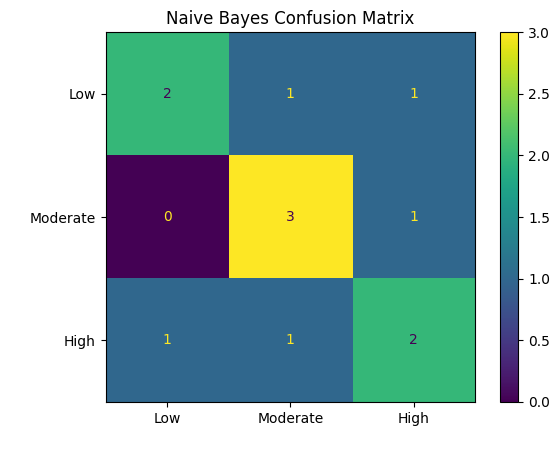

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test,pred_y,display_labels=['Low', 'Moderate', 'High'])
plt.title('Naive Bayes Confusion Matrix')
plt.ylabel(' ')
plt.xlabel(' ')
plt.show()

In [ ]:
nb_data = park_agg[["Park Name"] + nb_feats + ["Recreation Visits", "Crowding Levels"]].copy()
nb_data.to_csv("../data/clean/naive_bayes_data.csv",index=False)

For the Naive Bayes analysis results, the supervised classification system could classify national parks into different levels of visitation: 'Low' visitation, 'Medium' visitation, and 'High' visitation better than random guessing. From the report above, the accuracy level is 0.583, or 58.3%. Since random guessing would have had accuracy of 33%, the model performed better than chance. The first row shows that 2 'Low' visitation parks were correctly predicted as 'Low', 1 'Low' visitation park was incorrectly predicted as 'Medium', and 1 'Low' visitation park was incorrectly predicted as 'High'. The second row shows that 3 'Medium' visitation parks were correctly classified as 'Medium', 1 'Medium' visitation park was wrongly classified as 'High', and none were classified as 'Low'. The last row shows that 2 'High' visitation parks were correctly identified, 1 was wrongly classified as 'Low', and 1 was wrongly classified as 'Medium'.